<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustering_ModernBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
#### Topic modelling by embedding vector space with ModerBERT

## **Step 1: Install packages and required libraries**


---

This step sets up the environment by installing necessary packages and importing relevant libraries.

In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import BERTopic
from turftopic import Top2Vec
from tqdm import tqdm

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score


# Required libraries for dendrogram and visualisation
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram


# Google drive library
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 2: Load and read original dataset**


---

In this step, the dataset is loaded from Google Drive or Google Colab root (or any other online coding platform). The dataset is a sample drived from original source which consists of 10,000 PubMed abstracts with accompanying metadata like title and year. This dataset downloaded from a Graph Database source.

### Several methods used to load and read dataset:
 - Goodle drive files
 - Google colab root files

In [3]:
# Read and Load dataset
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       10000 non-null  object
 2   abstract    10000 non-null  object
 3   year        10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [5]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].tolist()

# Display a few samples to verify
abstracts[:5]

['Background Niemann-Pick disease type C (NPC) is a lysosomal storage disorder with severe prognosis. Disease-specific therapy is crucial to prevent disease progression; however, diagnosing NPC is quite difficult because of remarkably variable clinical presentations. The NPC Suspicion Index (NPC-SI) was developed to overcome this problem. Identifying preclinical cases is important for prevention and therapy. Here, we report three newly diagnosed NPC cases, one typical juvenile-onset case and the cases of two sisters with symptoms neurologically/psychiatrically indistinguishable from dystonia and schizophrenia, respectively. Case presentation In Case 1, a 25-year-old man presented with a 14-year history of intellectual disability, clumsiness, spastic ataxia, dysphagia, and frequent falls. Neurological examination revealed vertical supranuclear gaze palsy and involuntary movements. Ultrasonography revealed mild splenomegaly, and filipin staining of skin fibroblasts was positive with a va

## **Step 3: Extract Embeddings using ModerBERT**

---
Although embeddings were originally designed to be extracted with the ModernBERT model using GPU or CPU, this step was commented out and replaced with loading pre-generated embeddings for efficiency.

  - Use "ModernBERT" to extract embeddings
  - Use pre-embeddings extracted by ModernBERT as csv file

In [ ]:
# Load ModernBERT tokenizer and model from Hugging Face
MODEL_NAME = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

### Extract embeddings by ModernBERT
1. Force to use GPU for embeddings
2. Extract embedding by CPU

In [ ]:
# # Move model to GPU if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)

# # Function to get embeddings for a list of texts
# def get_embeddings(texts, tokenizer, model):
#     model.eval()
#     device = next(model.parameters()).device  # ensures model and inputs are on same device
#     embeddings = []

#     with torch.no_grad():
#         for text in texts:
#             inputs = tokenizer(text, return_tensors="pt", truncation=False, padding=True)
#             inputs = {k: v.to(device) for k, v in inputs.items()}  # move inputs to GPU
#             outputs = model(**inputs)
#             cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()  # back to CPU
#             embeddings.append(cls_embedding)

#     return embeddings

################################################################################

# # Function to get embeddings for a list of texts
# def get_embeddings(texts, tokenizer, model):
#     model.eval()
#     embeddings = []

#     with torch.no_grad():
#         for text in texts:
#             inputs = tokenizer(text, return_tensors="pt", truncation=False, padding=True)
#             outputs = model(**inputs)
#             # Use [CLS] token embedding (first token)
#             cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
#             embeddings.append(cls_embedding)

#     return embeddings

In [ ]:
# # Wrap the texts with tqdm for progress visualization
# abstracts = abstracts
# abstracts_with_progress = tqdm(abstracts, desc="Embedding abstracts")

# # Call the function with tqdm-wrapped list
# abstract_embeddings = get_embeddings(abstracts_with_progress, tokenizer, model)

In [ ]:
# # save abstract_embeddings into csv file
# np.savetxt("abstract_embeddings.csv", abstract_embeddings, delimiter=",")

### Use Pre-embeddings as csv file
Instead of computing embeddings on-the-fly, the analysis loads embeddings from a CSV file based on previous execution of ModernBERT to extrat embedding. This method used because of lack of computational resource (GPU).

In [14]:
# Use pre-embeddings csv file
pre_embeddings = np.loadtxt("/content/drive/MyDrive/Internship/Datasets/SampleDataset/Sample_Dataset_Abstract_Embeddings.csv", delimiter=",")


# Get embeddings from csv file
abstract_embeddings = pre_embeddings

abstract_embeddings

array([[ 0.30497697, -0.20869878, -0.18874036, ..., -1.1213119 ,
         0.63652396, -0.54932749],
       [ 0.46238339, -0.65232009,  0.29970372, ..., -1.25551248,
         1.12826502, -0.34438741],
       [-0.23266809, -0.51089746, -0.0102424 , ..., -1.5995301 ,
         0.76797158, -0.77237844],
       ...,
       [-0.27163851, -0.38257405, -0.21645126, ..., -1.50330627,
         0.93543106, -0.24376546],
       [ 0.09230014, -0.67846876, -0.27810726, ..., -1.78912866,
         0.487746  , -0.64731061],
       [-0.08118434, -0.49155283, -0.31141263, ..., -1.76977527,
         0.94671571, -0.40294534]])

In [15]:
# Show shape of the first embedding
len(abstract_embeddings), abstract_embeddings[0].shape

# Show embeddings matrix and Check the dimention of each eambeding
embeddings = np.array(abstract_embeddings)
print(embeddings)

[[ 0.30497697 -0.20869878 -0.18874036 ... -1.1213119   0.63652396
  -0.54932749]
 [ 0.46238339 -0.65232009  0.29970372 ... -1.25551248  1.12826502
  -0.34438741]
 [-0.23266809 -0.51089746 -0.0102424  ... -1.5995301   0.76797158
  -0.77237844]
 ...
 [-0.27163851 -0.38257405 -0.21645126 ... -1.50330627  0.93543106
  -0.24376546]
 [ 0.09230014 -0.67846876 -0.27810726 ... -1.78912866  0.487746
  -0.64731061]
 [-0.08118434 -0.49155283 -0.31141263 ... -1.76977527  0.94671571
  -0.40294534]]


## **Step 4: Topic Modelling And Clustering by Vec2Top default model**
- In this notebook the Turftopics libraries for modeling, clustering, visualisation and topic nameing are used. Turftopic is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

---
The **turftopic.Top2Vec** model was used for unsupervised topic modeling using the pre-computed embeddings.

**Result:**
The initial model discovered 6 topics.

The basic information and first visualisation of the topics are shown below. Also, The hierarchical topic structure was maintained and not reduced, as the number of detected topics was already below the threshold.

In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=MODEL_NAME, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [17]:
topic_data

TopicData
├── corpus (10000)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (6, 10027)
├── document_topic_matrix (10000, 6)
├── document_representation (10000, 768)
├── transform
├── topic_names (6)
├── has_negative_side
└── hierarchy

In [ ]:
!pip install topic-wizard

In [20]:
topic_data.figures.topic_map()

In [21]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ affymetrix, oncogenes, bronchiectasis, enhancer, immunoassays, amygdala, sagittal, carotenoids,      │
│          │ oncogenic, assessments                                                                               │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ slightly, assessments, etching, gg, mann, oncogenes, lysine, lysosomes, shed, sagittal               │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ assessments, affymetrix, etching, oncogenes, immunoassays, germplasm, lysosomes, gg, sagittal, mann  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ assessments, etching, affymetrix, amygdala, sirnas, sagittal, oncogenes, hepatoma, mann, lysosomes   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ assessments, oncogenes, etching, slightly, affymetrix, gg, mann, achievable, lysosomes, sagittal     │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ assessments, retinopathy, oncogenes, etching, lysosomes, affymetrix, suggests, sagittal,             │
│          │ proteinuria, sirnas                                                                                  │
└──────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────┘

In [22]:
# Cluster model hierarchy
model.hierarchy.cut(3).plot_tree()

In [23]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

/usr/local/lib/python3.11/dist-packages/turftopic/models/_hierarchical_clusters.py:276: UserWarning:

Number of clusters is already 5 <= 25, nothing to do.



Root: 
├── -1: affymetrix, oncogenes, bronchiectasis, enhancer, immunoassays, amygdala, sagittal, carotenoids,
│   oncogenic, 
│   assessments
├── 0: slightly, assessments, etching, gg, mann, oncogenes, lysine, lysosomes, shed, sagittal
├── 1: assessments, affymetrix, etching, oncogenes, immunoassays, germplasm, lysosomes, gg, sagittal,
│   mann
├── 2: assessments, etching, affymetrix, amygdala, sirnas, sagittal, oncogenes, hepatoma, mann, 
│   lysosomes
├── 3: assessments, oncogenes, etching, slightly, affymetrix, gg, mann, achievable, lysosomes, 
│   sagittal
└── 4: assessments, retinopathy, oncogenes, etching, lysosomes, affymetrix, suggests, sagittal, 
    proteinuria, sirnas



In [ ]:
# # Model hierarchy after merging topics
# fig = model.hierarchy[156].plot_tree()
# fig.show()

In [24]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:258: UserWarning:

Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.



## **Step 5: Topic Modelling And Clustering by BERTopic default model**


---


BERTopic, a transformer-based topic modeling technique, was applied using the same ModernBERT embeddings. This approach leverages UMAP and HDBSCAN for clustering.

** Result:** BERTopic discovered 7 meaningful clusters from the abstracts.

The basic information and first visualisation of the topics are shown below. Also, The hierarchical topic structure was maintained and not reduced, as the number of detected topics was already below the threshold.


In [26]:
# Show embeddings matrix and Check the dimention of each eambeding
embeddings1 = np.array(abstract_embeddings)
print(embeddings1,"\n\n")

[[ 0.30497697 -0.20869878 -0.18874036 ... -1.1213119   0.63652396
  -0.54932749]
 [ 0.46238339 -0.65232009  0.29970372 ... -1.25551248  1.12826502
  -0.34438741]
 [-0.23266809 -0.51089746 -0.0102424  ... -1.5995301   0.76797158
  -0.77237844]
 ...
 [-0.27163851 -0.38257405 -0.21645126 ... -1.50330627  0.93543106
  -0.24376546]
 [ 0.09230014 -0.67846876 -0.27810726 ... -1.78912866  0.487746
  -0.64731061]
 [-0.08118434 -0.49155283 -0.31141263 ... -1.76977527  0.94671571
  -0.40294534]] 




In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder="answerdotai/ModernBERT-base", random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings1)

In [28]:
topic_data1

TopicData
├── corpus (10000)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (7, 10027)
├── document_topic_matrix (10000, 7)
├── document_representation (10000, 768)
├── transform
├── topic_names (7)
├── has_negative_side
└── hierarchy

In [29]:
topic_data1.classes

array([-1,  0,  1,  2,  3,  4,  5])

In [30]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                        ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ egfr, cc, pic, 05, thrombin, tnm, fibrinogen, dog, diagnosis, tm                       │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ patients, study, results, methods, background, health, group, using, conclusions, data │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ des, une, les, la, le, dans, et, en, cas, est                                          │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ electron, metal, reaction, gender, fl, pt, lewis, electrochemical, bank, bond          │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ patients, study, ich, heat, results, mortality, background, type, methods, age         │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ cells, cell, study, using, results, high, based, expression, activity, used            │
├──────────┼────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ cells, patients, hiv, pod, reactivity, men, results, tick, group, tidal                │
└──────────┴────────────────────────────────────────────────────────────────────────────────────────┘

In [32]:
topic_data1.figures.topic_map()

In [33]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [34]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

/usr/local/lib/python3.11/dist-packages/turftopic/models/_hierarchical_clusters.py:276: UserWarning:

Number of clusters is already 6 <= 25, nothing to do.



Root: 
├── -1: egfr, cc, pic, 05, thrombin, tnm, fibrinogen, dog, diagnosis, tm
├── 0: patients, study, results, methods, background, health, group, using, conclusions, data
├── 1: des, une, les, la, le, dans, et, en, cas, est
├── 2: electron, metal, reaction, gender, fl, pt, lewis, electrochemical, bank, bond
├── 3: patients, study, ich, heat, results, mortality, background, type, methods, age
├── 4: cells, cell, study, using, results, high, based, expression, activity, used
└── 5: cells, patients, hiv, pod, reactivity, men, results, tick, group, tidal



## **Step 6:Topic Namer**

---
Turftopic lets you utilise Large Language Models for generating human-readable topic names. This is done by instructing the language model to generate a topic name based on the keywords the topic model assigns as the most important for a given topic.


### Topic Namer for Vec2Top model
For each clusters drived by Vec2Top, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

In [ ]:
# Load topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [ ]:
renamed_topics = model.topic_names
renamed_topics

['Oncogenic Enhancer Assessment',
 'slightly-oncogene-lysine-lysosomal-etching',
 'Biotechnology',
 'Gene Expression Analysis',
 'Genetic Expression Gene Profiling',
 '"Eyeball Examination"']

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                 ┃ Highest Ranking                                         ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Oncogenic Enhancer Assessment              │ affymetrix, oncogenes, bronchiectasis, enhancer,        │
│          │                                            │ immunoassays, amygdala, sagittal, carotenoids,          │
│          │                                            │ oncogenic, assessments                                  │
├──────────┼────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│        0 │ slightly-oncogene-lysine-lysosomal-etching │ slightly, assessments, etching, gg, mann, oncogenes,    │
│          │                                            │ lysine, lysosomes, shed, sagittal                       │
├──────────┼────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│        1 │ Biotechnology                              │ assessments, affymetrix, etching, oncogenes,            │
│          │                                            │ immunoassays, germplasm, lysosomes, gg, sagittal, mann  │
├──────────┼────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│        2 │ Gene Expression Analysis                   │ assessments, etching, affymetrix, amygdala, sirnas,     │
│          │                                            │ sagittal, oncogenes, hepatoma, mann, lysosomes          │
├──────────┼────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│        3 │ Genetic Expression Gene Profiling          │ assessments, oncogenes, etching, slightly, affymetrix,  │
│          │                                            │ gg, mann, achievable, lysosomes, sagittal               │
├──────────┼────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│        4 │ "Eyeball Examination"                      │ assessments, retinopathy, oncogenes, etching,           │
│          │                                            │ lysosomes, affymetrix, suggests, sagittal, proteinuria, │
│          │                                            │ sirnas                                                  │
└──────────┴────────────────────────────────────────────┴─────────────────────────────────────────────────────────┘

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:258: UserWarning:

Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.



<InteractiveFigure width=100% height=800>
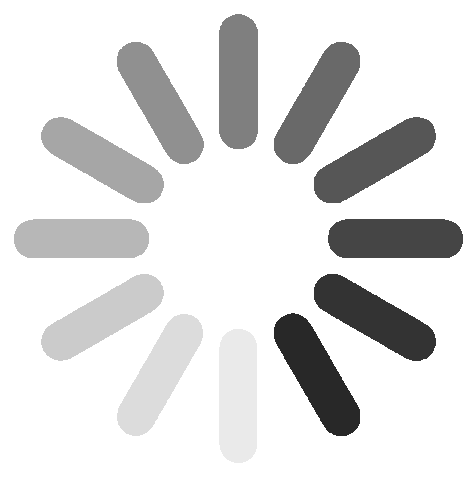

In [25]:
fig = model.plot_clusters_datamapplot()
fig.save("clusters_visualization.html")
fig

### Topic Namer for BERTopic Model
For each clusters drived by BERTopic, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

Here A more structured prompt was used to guide the LLM into generating domain-relevant topic titles. These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

These generated labels improve the interpretability of the topic clusters for human readers and downstream reporting.



In [ ]:
# Costumize topic namer
prompt = (
  "You are naming topics for a machine learning research paper."
  "Given these keywords: {keywords}, return a short and descriptive topic title."
  "Limit to 2-3 words. Return only the topic name."
)

namer = LLMTopicNamer(
    model_name="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    prompt_template=prompt,
    # max_keywords=10,
    # temperature=0
)
model1.rename_topics(namer)

In [ ]:
renamed_topics1 = model1.topic_names
renamed_topics1

['Fibrinogen Dysregulation in Dogs',
 'Personalized Health Outcomes Using Machine Learning in Medical Research',
 'Des cas',
 'Electron-Metal Reaction',
 'Ich-type Heat-related Mortality in Elderly Patients.',
 'Cell Expression Study Using High-Activity Results',
 'HIV Reactivity in Pod-associated Tidal Men']

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                        ┃ Highest Ranking                                  ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Fibrinogen Dysregulation in Dogs                  │ egfr, cc, pic, 05, thrombin, tnm, fibrinogen,    │
│          │                                                   │ dog, diagnosis, tm                               │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        0 │ Personalized Health Outcomes Using Machine        │ patients, study, results, methods, background,   │
│          │ Learning in Medical Research                      │ health, group, using, conclusions, data          │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        1 │ Des cas                                           │ des, une, les, la, le, dans, et, en, cas, est    │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        2 │ Electron-Metal Reaction                           │ electron, metal, reaction, gender, fl, pt,       │
│          │                                                   │ lewis, electrochemical, bank, bond               │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        3 │ Ich-type Heat-related Mortality in Elderly        │ patients, study, ich, heat, results, mortality,  │
│          │ Patients.                                         │ background, type, methods, age                   │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        4 │ Cell Expression Study Using High-Activity Results │ cells, cell, study, using, results, high, based, │
│          │                                                   │ expression, activity, used                       │
├──────────┼───────────────────────────────────────────────────┼──────────────────────────────────────────────────┤
│        5 │ HIV Reactivity in Pod-associated Tidal Men        │ cells, patients, hiv, pod, reactivity, men,      │
│          │                                                   │ results, tick, group, tidal                      │
└──────────┴───────────────────────────────────────────────────┴──────────────────────────────────────────────────┘

## **Step 7: Visualization**

---

To better understand the relationships between generated topics, hierarchical clustering was applied to the topic-term matrices from both models. Cosine distances between topics were visualized using dendrograms.


### Dendrogram For Vec2Top Model
**Steps:**
1. Extracted topic-term matrix and topic names.
2. Calculated cosine distance between topics.
3. Applied hierarchical clustering (Ward's method).
4. Plotted the dendrogram.

**Visualization Outcome:**
1. Topics such as "Gene Expression Analysis" and "Genetic Expression Gene Profiling" clustered closely.
2. Topic distances were visibly interpretable.
3. Warning indicated a potential formatting issue, but the dendrogram was successfully rendered.

In [ ]:
# Extract topic names and embeddings from the model
topic_names = renamed_topics
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['Oncogenic Enhancer Assessment',
  'slightly-oncogene-lysine-lysosomal-etching',
  'Biotechnology',
  'Gene Expression Analysis',
  'Genetic Expression Gene Profiling',
  '"Eyeball Examination"'],
 array([[0.45976217, 0.63376377, 0.58041893, ..., 0.49750114, 0.53098307,
         0.58152062],
        [0.5998747 , 0.73272306, 0.70542601, ..., 0.64233918, 0.66746517,
         0.67467532],
        [0.58214896, 0.73183525, 0.69316252, ..., 0.62604448, 0.6528995 ,
         0.66605247],
        [0.55503144, 0.7118494 , 0.66062566, ..., 0.60703081, 0.62630853,
         0.63923287],
        [0.61131218, 0.74119227, 0.7181292 , ..., 0.64881619, 0.6779812 ,
         0.69185815],
        [0.53350469, 0.69546498, 0.6477059 , ..., 0.58041852, 0.60465234,
         0.61489108]]))

/tmp/ipython-input-62-3160231143.py:8: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



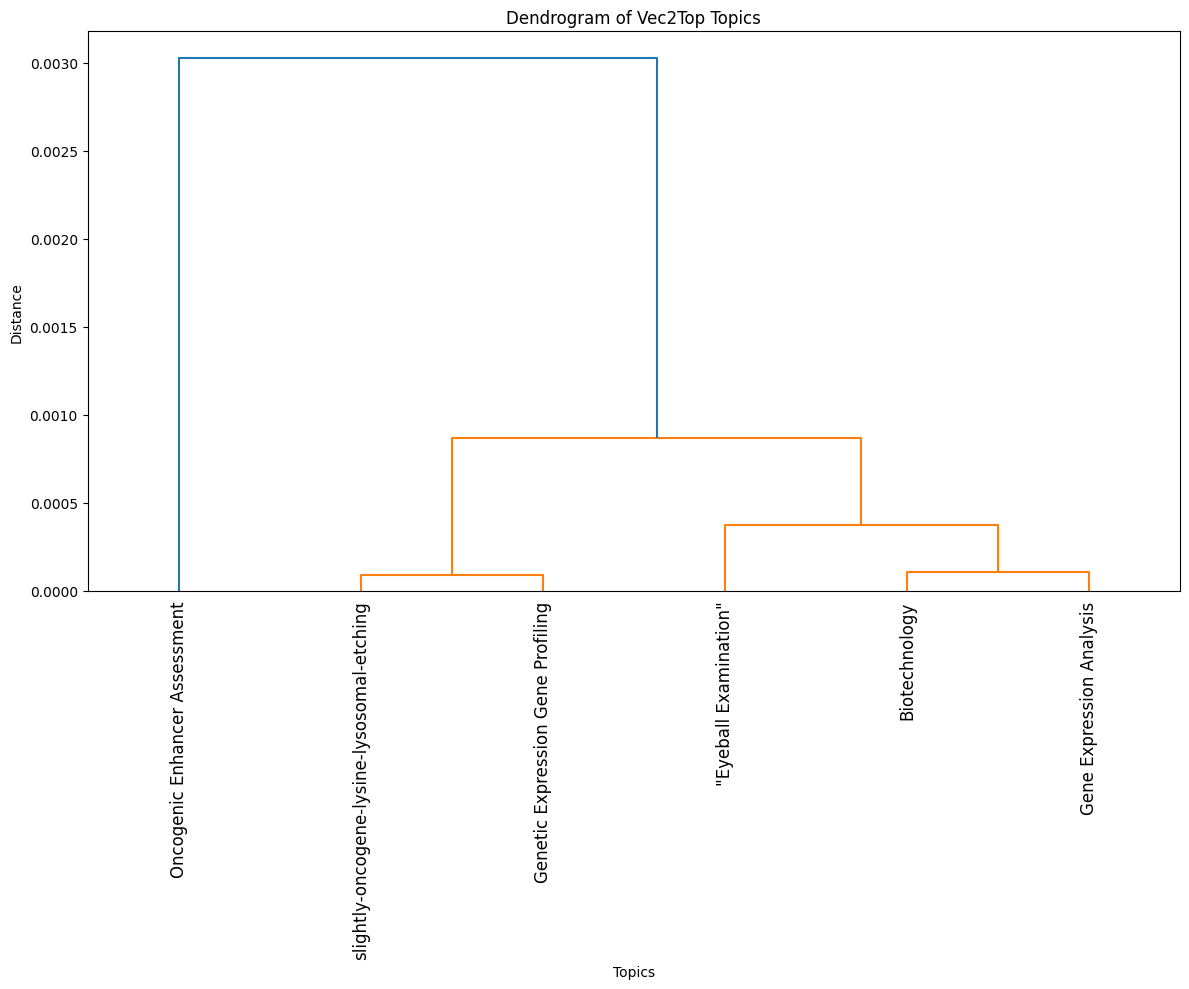

In [ ]:
# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# # Plot the dendrogram
# plt.figure(figsize=(12, 6))
# dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90)
# plt.title("Dendrogram of Vec2Top Topics")
# plt.xlabel("Topics")
# plt.ylabel("Distance")
# plt.tight_layout()
# plt.show()

# Plot the dendrogram
plt.figure(figsize=(12, 10))
dendrogram(linkage_matrix, labels=topic_names, leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Dendrogram For BERTopic Model
**Steps:**
1. Used topic-term matrix from BERTopic model.
2. Computed cosine distance between topic vectors.
3. Plotted a dendrogram to show topic hierarchy.

**Visualization Outcome:**
1. Topics such as "Cell Expression Study..." and "HIV Reactivity..." appeared in adjacent branches.
2. Some display warnings occurred due to layout limitations, but clustering was clearly rendered.




In [ ]:
# Extract topic names and embeddings from the model
topic_names1 = renamed_topics1
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names1, topic_embeddings1

(['Fibrinogen Dysregulation in Dogs',
  'Personalized Health Outcomes Using Machine Learning in Medical Research',
  'Des cas',
  'Electron-Metal Reaction',
  'Ich-type Heat-related Mortality in Elderly Patients.',
  'Cell Expression Study Using High-Activity Results',
  'HIV Reactivity in Pod-associated Tidal Men'],
 array([[  14.64063885,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [ 497.78172076,  792.19899771,  141.94570207, ...,  173.13057351,
          399.99257927,   86.56528675],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        ...,
        [   0.        ,    6.49343441,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [ 344.05501288,  948.04142348,   79.84445742, ...,   95.22181543,
         1568.22487426,  181.78710218],
        [   7.32031942,    6.49343441,    0.        , ...,    0.        ,
            0.        , 

/tmp/ipython-input-60-1034578388.py:8: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/tmp/ipython-input-60-1034578388.py:25: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



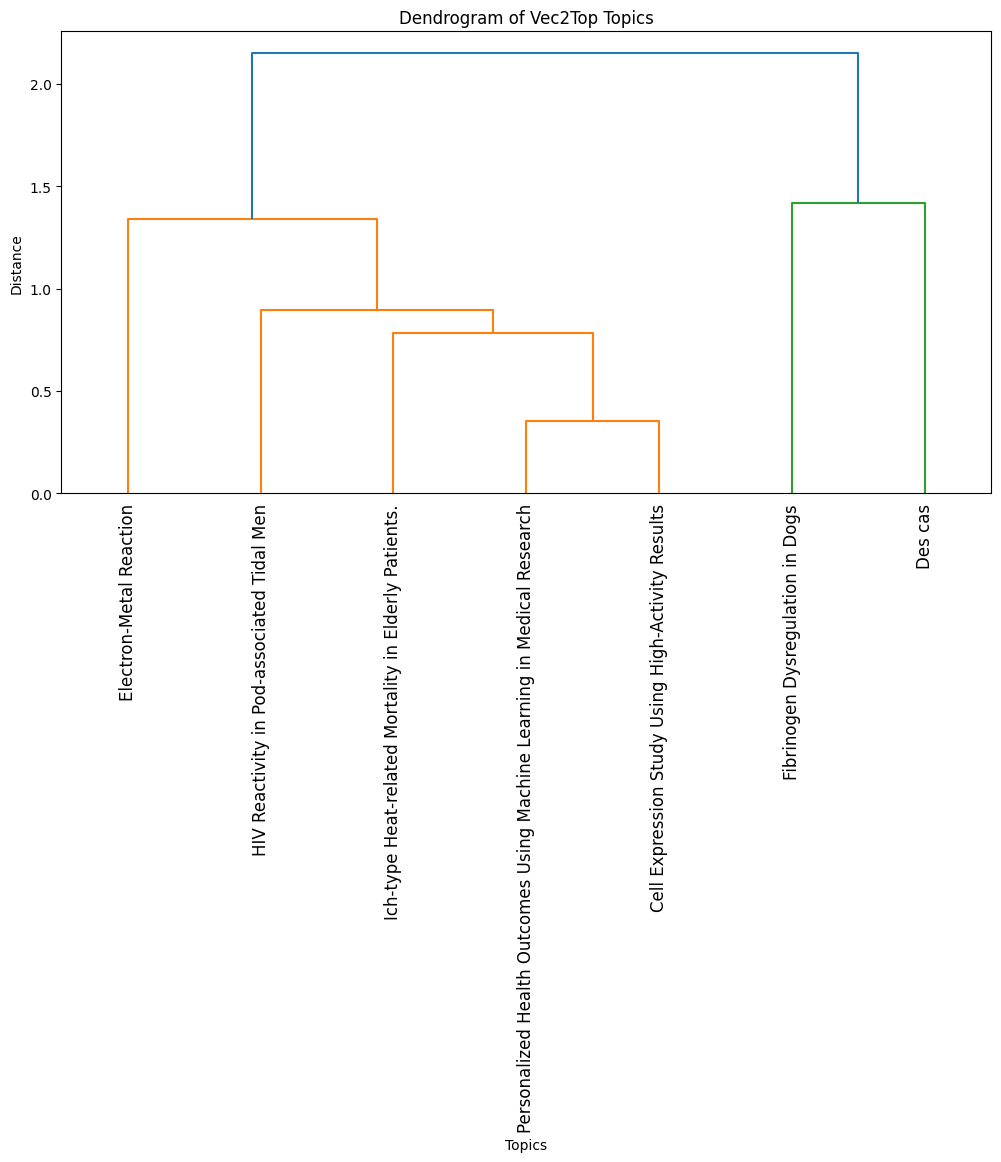

In [ ]:
# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

# Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# # Plot the dendrogram
# plt.figure(figsize=(12, 6))
# dendrogram(linkage_matrix1, labels=[f"Topic {i}" for i in range(len(topic_names1))], leaf_rotation=90)
# plt.title("Dendrogram of Vec2Top Topics")
# plt.xlabel("Topics")
# plt.ylabel("Distance")
# plt.tight_layout()
# plt.show()

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix1, labels=topic_names1, leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# **Step 8: Evaluation Models By Several Metrics**

---

This step evaluates the performance of the Vec2Top and BERTopic models using the following metrics:

- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

These metrics reflect cluster cohesion, separation, and structure quality.

## **Vec2Top Evaluation**
**Summary for Vec2Top topics evaluation:**
1. Silhouette Score
  - Score: 0.1239
  - Interpretation: Moderate clustering quality. A value closer to 1 indicates dense and well-separated clusters.

2. Calinski-Harabasz Score
  - Score: 321.6611
  - Interpretation: Higher values indicate better-defined clusters. This score suggests solid separation between clusters.

3. Davies-Bouldin Score
  - Score: 1.7618
  - Interpretation: Lower is better. This score reflects moderate inter-cluster separation.

**Summary for BERTopic topics evaluation:**
1. Silhouette Score
  - Score: 0.0207
  - Interpretation: Very low clustering structure; likely overlaps or loose clusters.

2. Calinski-Harabasz Score
  - Score: 121.9700
  - Interpretation: Significantly lower than Vec2Top, suggesting weaker structure.

3. Davies-Bouldin Score
  - Score: 3.7913
  - Interpretation: High score implies poor separation between topic clusters.

---

**Preliminary Conclusion:**
Based on all three metrics, Vec2Top outperforms BERTopic in terms of both cohesion and separation of abstract embeddings.

### Preprocess

In [ ]:
# Get Cluster Labels
''' The `document_topic_matrix` in `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices = topic_data.document_topic_matrix.argmax(axis=1)
document_labels_indices

array([4, 4, 1, ..., 4, 4, 4])

In [ ]:
# # Extract all labels "4" and  in document_labels_indices and store in separated array
# labels_4 = document_labels_indices[document_labels_indices == 4]
# labels_4

In [ ]:
# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels = np.array(model.topic_names)[document_labels_indices]
document_labels

array(['3_assessments_oncogenes_etching_slightly',
       '3_assessments_oncogenes_etching_slightly',
       '0_slightly_assessments_etching_gg', ...,
       '3_assessments_oncogenes_etching_slightly',
       '3_assessments_oncogenes_etching_slightly',
       '3_assessments_oncogenes_etching_slightly'], dtype='<U47')

### Silhouette score
- Compute the mean Silhouette Coefficient of all samples.
- The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b). To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of. Note that Silhouette Coefficient is only defined if number of labels is 2 <= n_labels <= n_samples - 1.

  - 𝑎: mean distance between a sample and all other points in the same cluster.
  - 𝑏: mean distance between a sample and all points in the nearest (next best) cluster.
- Score range:
 - +1: The sample is far from neighboring clusters (good clustering).
 - 0: The sample is on or very close to the decision boundary.
 - −1: The sample may have been assigned to the wrong cluster.

In [ ]:
# Prepare Data for Scoring
''' The silhouette score cannot be calculated for documents that are considered outliers (labeled as -1).
We will filter out these outliers from both our embeddings and our labels.'''

# Create a mask to select only non-outlier documents
non_outlier_mask = document_labels != -1

# Apply the mask to your embeddings and labels
embeddings_filtered = embeddings[non_outlier_mask]
labels_filtered = document_labels[non_outlier_mask]

In [ ]:
# Calculate and Print the Score
# Check if we have at least 2 clusters, which is required for the calculation.
if len(set(labels_filtered)) > 1:
    # Calculate the silhouette score
    # It compares the mean intra-cluster distance to the mean nearest-cluster distance for each sample.
    score = silhouette_score(embeddings_filtered, labels_filtered)

    print(f"Number of documents used for scoring (excluding outliers): {len(labels_filtered)}")
    print(f"Number of clusters found (excluding outliers): {len(set(labels_filtered))}")
    print(f"Vec2Top Silhouette Score: {score:.4f}")
else:
    print("Silhouette score could not be calculated.")
    print("This is likely because only one cluster remains after removing outliers.")

Number of documents used for scoring (excluding outliers): 10000
Number of clusters found (excluding outliers): 6
Vec2Top Silhouette Score: 0.1239


### Calinski_Harabasz Score
 - Higher Calinski-Harabasz score relates to a model with better defined clusters

In [ ]:
# Extract cluster labels from the document_topic_matrix
cluster_labels = np.argmax(topic_data.document_topic_matrix, axis=1)

# Calculate the Calinski-Harabasz score
ch_score = calinski_harabasz_score(embeddings, cluster_labels)

print(f"Vec2Top Calinski-Harabasz Score: {ch_score:.4f}")

Vec2Top Calinski-Harabasz Score: 321.6611


### Davies_Bouldin score
 - The score is defined as the average similarity of each cluster to its most similar neighboring cluster. The similarity is computed as the ratio of within-cluster distances to between-cluster distances. Therefore, clusters that are compact (low within-cluster distance) and well-separated (high between-cluster distance) will have lower similarity values.

 A lower score indicates better clustering, with the minimum possible score being zero. This occurs when clusters are perfectly separated and internally cohesive.
  - Ideal Clustering: Within-cluster distance: Low and Between-cluster distance: High
  - Moderate Clustering: Within-cluster distance: Medium and Between-cluster distance: Medium
  - Poor Clustering: Within-cluster distance: High and Between-cluster distance: Low

In [ ]:
# Calculate the davies_bouldin_score
db_score = davies_bouldin_score(embeddings, cluster_labels)

print(f"Vec2Top Davies_Bouldin Score: {db_score:.4f}")

Vec2Top Davies_Bouldin Score: 1.7618


## **BERTopic Evaluation**

### Preprocess

In [ ]:
# Get Cluster Labels
''' The `document_topic_matrix` in your `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices1 = topic_data1.document_topic_matrix.argmax(axis=1)
document_labels_indices1

array([1, 1, 1, ..., 5, 5, 5])

In [ ]:
# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels1 = np.array(model1.topic_names)[document_labels_indices1]
document_labels1

array(['0_patients_study_results_methods',
       '0_patients_study_results_methods',
       '0_patients_study_results_methods', ...,
       '4_cells_cell_study_using', '4_cells_cell_study_using',
       '4_cells_cell_study_using'], dtype='<U32')

### Silhouette score

In [ ]:
# Prepare Data for Scoring
''' The silhouette score cannot be calculated for documents that are considered outliers (labeled as -1).
We will filter out these outliers from both our embeddings and our labels.'''

# Create a mask to select only non-outlier documents
non_outlier_mask1 = document_labels1 != -1

# Apply the mask to your embeddings and labels
embeddings_filtered1 = embeddings1[non_outlier_mask1]
labels_filtered1 = document_labels1[non_outlier_mask1]

In [ ]:
# Calculate and Print the Score
# Check if we have at least 2 clusters, which is required for the calculation.
if len(set(labels_filtered1)) > 1:
    # Calculate the silhouette score
    # It compares the mean intra-cluster distance to the mean nearest-cluster distance for each sample.
    score1 = silhouette_score(embeddings_filtered1, labels_filtered1)

    print(f"Number of documents used for scoring (excluding outliers): {len(labels_filtered1)}")
    print(f"Number of clusters found (excluding outliers): {len(set(labels_filtered1))}")
    print(f"BERTopic Silhouette Score: {score1:.4f}")
else:
    print("Silhouette score could not be calculated.")
    print("This is likely because only one cluster remains after removing outliers.")

Number of documents used for scoring (excluding outliers): 10000
Number of clusters found (excluding outliers): 7
BERTopic Silhouette Score: 0.0207


### Calinski_Harabasz Score

In [ ]:
# Extract cluster labels from the document_topic_matrix
cluster_labels1 = np.argmax(topic_data1.document_topic_matrix, axis=1)

# Calculate the Calinski-Harabasz Index
ch_score1 = calinski_harabasz_score(embeddings1, cluster_labels1)

print(f"BERTopic Calinski-Harabasz Score: {ch_score1:.4f}")

Vec2Top Calinski-Harabasz Score: 121.9700


### Davies_Bouldin score

In [ ]:
# Calculate the davies_bouldin_score
db_score = davies_bouldin_score(embeddings1, cluster_labels1)

print(f"BERTopic Davies_Bouldin Score: {db_score:.4f}")

BERTopic Davies_Bouldin Score: 3.7913


## **Step 9: Comparison of Topic Assignments**

---

This section compares how well Vec2Top and BERTopic agree in assigning documents to topic clusters using external evaluation metrics.

**Summary of topic models evaluation**
Here’s the final analytical section of your report, comparing clustering **agreement and similarity** between the two models:

---

### 🔁 Adjusted Rand Index (ARI)

**Score:** 0.294

* Measures exact match between clustering results.
* **0.0 = random match**, **1.0 = perfect match**.
* This score indicates a **moderate level of agreement** between the two models.

---

### 🔁 Normalized Mutual Information (NMI)

**Scores:**

* Arithmetic mean: 0.226

* Geometric mean: 0.228

* Indicates **shared information** between the clusterings.

* Range: **\[0.0, 1.0]**, where 1.0 means complete overlap.

* These values indicate **partial correlation** in topic assignment patterns.

---

### 🔁 Homogeneity, Completeness, and V-measure

| Metric           | Score |
| ---------------- | ----- |
| **Homogeneity**  | 0.258 |
| **Completeness** | 0.201 |
| **V-measure**    | 0.226 |

* **Homogeneity:** Measures if each cluster contains only documents of a single class.
* **Completeness:** Measures if all members of a class are assigned to the same cluster.
* **V-measure:** Harmonic mean of the two.

These low-to-moderate values confirm that while some topical alignment exists between Vec2Top and BERTopic, their clustering logic differs.

---


### adjusted_rand_score
- Given the knowledge of the **ground truth class** assignments labels_true and our clustering algorithm assignments of the same samples labels_pred, the (adjusted or unadjusted) Rand index is a function that measures the similarity of the two assignments
  - 1.0 → Perfect match between both models.
  - 0.0 → No better than random.
  - < 0 → Worse than random agreement (rare, but possible).

In [ ]:
# Prepare data as true_label and pre_label
Vec2Top_labels = document_labels_indices
BERTopic_labels = document_labels_indices1

Vec2Top_labels, BERTopic_labels

(array([4, 4, 1, ..., 4, 4, 4]), array([1, 1, 1, ..., 5, 5, 5]))

In [ ]:
# Calculate adjusted_rand_score
ars_score = adjusted_rand_score(Vec2Top_labels, BERTopic_labels)

print(f"Adjusted Rand Score between BERTopic and Vec2Top: {ars_score:.3f}")

Adjusted Rand Score between BERTopic and Vec2Top: 0.294


### normalized_mutual_info_score
 - Normalized Mutual Information (NMI) is a normalization of the Mutual Information (MI) score to scale the results between 0 (no mutual information) and 1 (perfect correlation). In this function, mutual information is normalized by some generalized mean of H(labels_true) and H(labels_pred)), defined by the average_method.
 - Score between 0.0 and 1.0 in normalized nats (based on the natural logarithm)
  - 1.0 → Stands for perfectly complete labeling.

In [ ]:
# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='arithmetic') # default method

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='geometric')

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

NMI Score between BERTopic and Vec2Top: 0.226
NMI Score between BERTopic and Vec2Top: 0.228


### homogeneity_score, completeness_score, v_measure_score
 - Homogeneity:
  - Definition: A clustering result satisfies homogeneity if each cluster contains only members of a single class.
  - Interpretation: If a cluster has mixed classes, homogeneity decreases.
 - Completeness:
  - Definition: A clustering result satisfies completeness if all members of a given class are assigned to the same cluster.
  - Interpretation: If samples from the same class are spread across multiple clusters, completeness decreases.
 - V-measure:
  - Definition: The V-measure is the harmonic mean of homogeneity and completeness.
 - All three scores range from 0.0 to 1.0:
  - 0.0: worst possible clustering.
  - 1.0: perfect match with ground truth.



In [ ]:
# Calculate homogeneity_score
homogeneity_score = homogeneity_score(Vec2Top_labels, BERTopic_labels)

# Calculate completeness_score
completeness_score = completeness_score(Vec2Top_labels, BERTopic_labels)

# Calculate v_measure_score
v_measure_score = v_measure_score(Vec2Top_labels, BERTopic_labels)

print(f"Homogeneity Score between BERTopic and Vec2Top: {homogeneity_score:.3f}")
print(f"Completeness Score between BERTopic and Vec2Top: {completeness_score:.3f}")
print(f"V-Measure Score between BERTopic and Vec2Top: {v_measure_score:.3f}")

Homogeneity Score between BERTopic and Vec2Top: 0.258
Completeness Score between BERTopic and Vec2Top: 0.201
V-Measure Score between BERTopic and Vec2Top: 0.226


## Visualization For Metrics Evaluations

In [ ]:
# from umap import UMAP
# umap_emb = UMAP(n_neighbors=15, min_dist=0.1).fit_transform(embeddings)
# sns.scatterplot(x=umap_emb[:,0], y=umap_emb[:,1], hue=labels)

### Evaluation reults dataframe prepration

In [ ]:
# Create a dataframe of all evaluation results
performance_data = {
    'Metric': ['Silhouette', 'Silhouette', 'Calinski-Harabasz', 'Calinski-Harabasz', 'Davies-Bouldin', 'Davies-Bouldin'],
    'Model': ['Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic'],
    'Score': [0.1239, 0.0207, 321.6611, 121.9700, 1.7618, 3.7913]
}
performance_df = pd.DataFrame(performance_data)

agreement_data = {
    'Metric': ['Adjusted Rand', 'NMI', 'Homogeneity', 'Completeness', 'V-Measure'],
    'Score': [0.294, 0.226, 0.258, 0.201, 0.226]
}
agreement_df = pd.DataFrame(agreement_data)

print(performance_df, "\n")
print(agreement_df)

              Metric     Model     Score
0         Silhouette   Vec2Top    0.1239
1         Silhouette  BERTopic    0.0207
2  Calinski-Harabasz   Vec2Top  321.6611
3  Calinski-Harabasz  BERTopic  121.9700
4     Davies-Bouldin   Vec2Top    1.7618
5     Davies-Bouldin  BERTopic    3.7913 

          Metric  Score
0  Adjusted Rand  0.294
1            NMI  0.226
2    Homogeneity  0.258
3   Completeness  0.201
4      V-Measure  0.226


## 📊 **Plot 1: Model Performance Metrics**

This figure shows side-by-side bar charts comparing **Vec2Top** and **BERTopic** across three clustering performance metrics:

| Metric                | Interpretation                   | Vec2Top    | BERTopic |
| --------------------- | -------------------------------- | ---------- | -------- |
| **Silhouette Score**  | Higher = more distinct clusters  | **0.124**  | 0.021    |
| **Calinski-Harabasz** | Higher = well-separated clusters | **321.66** | 121.97   |
| **Davies-Bouldin**    | Lower = compact, non-overlapping | **1.76**   | 3.79     |

🟢 **Conclusion:**
**Vec2Top clearly outperforms BERTopic** in all three metrics, indicating more cohesive, better-separated, and well-defined clusters.

---


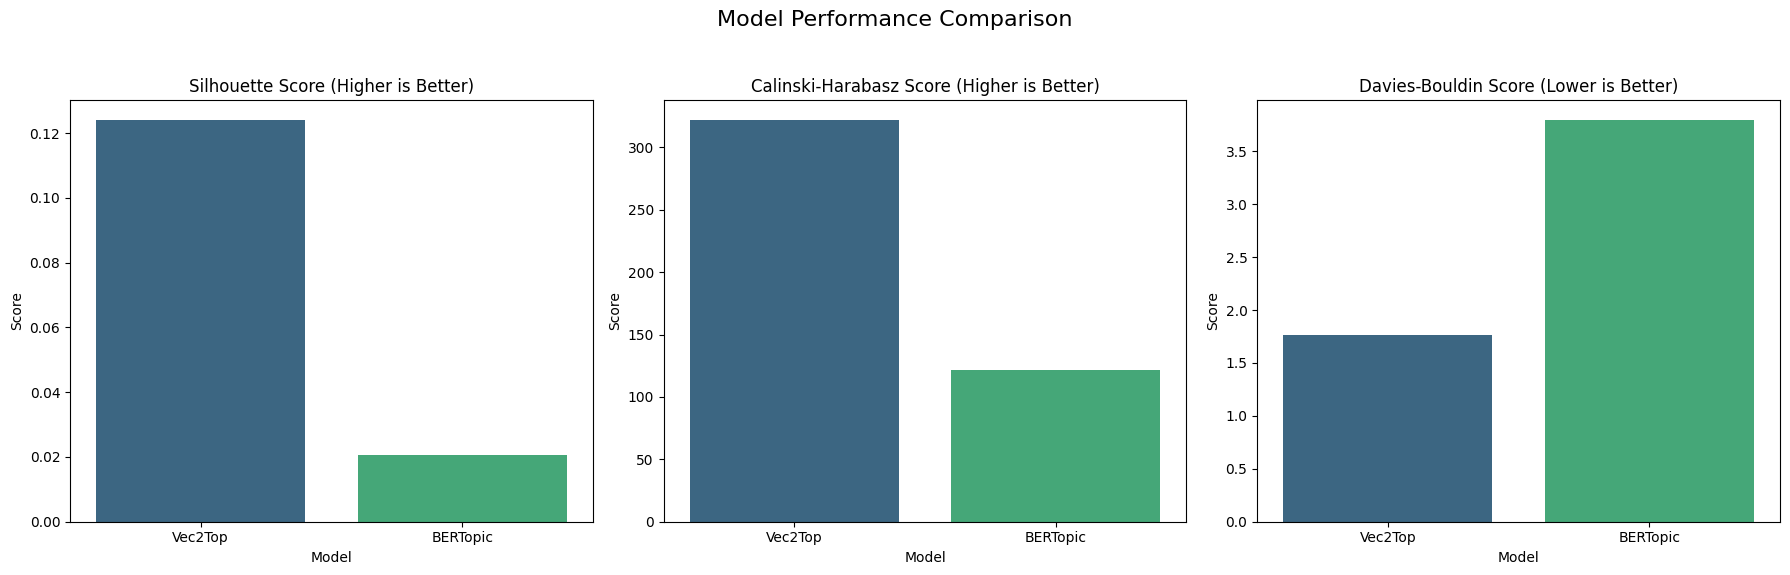

In [ ]:
# --- Plot 1: Model Performance Metrics ---
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Subplot 1: Silhouette Score
sns.barplot(ax=axes[0], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Silhouette'],
            hue='Model', palette='viridis', legend=False)
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')

# Subplot 2: Calinski-Harabasz Score
sns.barplot(ax=axes[1], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Calinski-Harabasz'],
            hue='Model', palette='viridis', legend=False)
axes[1].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')

# Subplot 3: Davies-Bouldin Score
sns.barplot(ax=axes[2], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Davies-Bouldin'],
            hue='Model', palette='viridis', legend=False)
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].set_ylabel('Score')
axes[2].set_xlabel('Model')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_performance_comparison.png')

## 🤝 **Plot 2: Model Agreement Metrics**

This horizontal bar chart displays how much the **topic assignments** between Vec2Top and BERTopic agree:

| Metric                           | Score |
| -------------------------------- | ----- |
| **Adjusted Rand Index**          | 0.294 |
| **Normalized Mutual Info (NMI)** | 0.226 |
| **Homogeneity**                  | 0.258 |
| **Completeness**                 | 0.201 |
| **V-Measure**                    | 0.226 |

🟡 **Conclusion:**
There is **moderate agreement** between the models. They capture **some similar topics** but differ significantly in cluster structure and assignments.

---

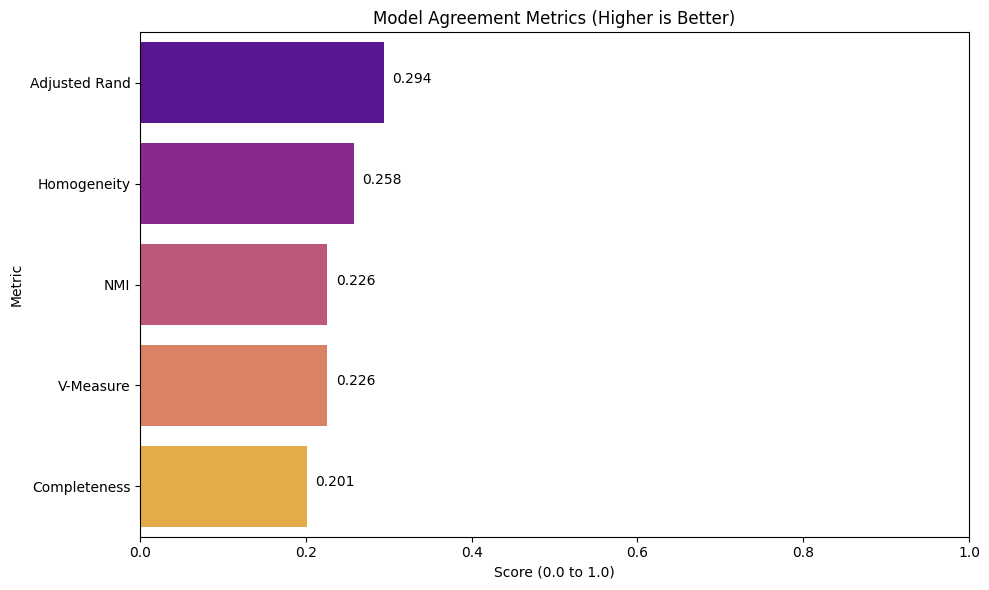

In [ ]:
# --- Plot 2: Model Agreement Metrics ---
plt.figure(figsize=(10, 6))
agreement_plot = sns.barplot(x='Score', y='Metric', data=agreement_df.sort_values('Score', ascending=False), hue='Metric', palette='plasma', orient='h')
plt.title('Model Agreement Metrics (Higher is Better)')
plt.xlabel('Score (0.0 to 1.0)')
plt.ylabel('Metric')
plt.xlim(0, 1)

# Add score labels to the bars
for index, value in enumerate(agreement_df.sort_values('Score', ascending=False)['Score']):
    plt.text(value + 0.01, index, f'{value:.3f}')

plt.tight_layout()
plt.savefig('model_agreement_metrics.png')

## Vec2Top Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex = topic_data.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters = len(np.unique(labels_ex))

# Compute centroids
centroids = np.array([
    embeddings[labels_ex == i].mean(axis=0) for i in range(num_clusters)
])

num_clusters, centroids

(6,
 array([[-0.34683668, -0.27970422, -1.88942525, ..., -1.07719228,
         -0.28804042, -0.86028398],
        [ 0.14208246, -0.55598738, -0.08488679, ..., -1.58944786,
          0.81766502, -0.69736316],
        [-0.05237957, -0.14312494, -0.32947745, ..., -1.98672269,
          0.5412086 , -0.21656825],
        [ 0.68290152, -0.40339093, -0.76242087, ..., -1.1654847 ,
          0.31248477, -0.62697486],
        [ 0.09800562, -0.54014321, -0.21086471, ..., -1.69025303,
          0.85939846, -0.45525298],
        [-0.33196827, -1.1912487 , -0.32553844, ..., -1.61202208,
          1.11875175, -0.3714472 ]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix = cosine_similarity(centroids)

# Calculate centroid by cosine similarity
distance_matrix = euclidean_distances(centroids)

similarity_matrix, distance_matrix

(array([[1.        , 0.69622544, 0.742598  , 0.70099259, 0.72289532,
         0.71068269],
        [0.69622544, 1.        , 0.96299672, 0.948437  , 0.98590754,
         0.93553337],
        [0.742598  , 0.96299672, 1.        , 0.95972508, 0.97438523,
         0.93334826],
        [0.70099259, 0.948437  , 0.95972508, 1.        , 0.92959322,
         0.8947363 ],
        [0.72289532, 0.98590754, 0.97438523, 0.92959322, 1.        ,
         0.93885435],
        [0.71068269, 0.93553337, 0.93334826, 0.8947363 , 0.93885435,
         1.        ]]),
 array([[ 0.        , 31.03531336, 28.80130134, 31.10078992, 29.68596451,
         30.22972675],
        [31.03531336,  0.        ,  9.81064527, 11.7438146 ,  5.96925222,
         12.7024851 ],
        [28.80130134,  9.81064527,  0.        , 10.4299462 ,  8.16927335,
         13.09170655],
        [31.10078992, 11.7438146 , 10.4299462 ,  0.        , 13.68502749,
         16.6458801 ],
        [29.68596451,  5.96925222,  8.16927335, 13.68502749,  0.

## 🧯 **Plot 3: Vec2Top Cluster-to-Cluster Cosine Similarity**

This heatmap visualizes the **cosine similarity between topic centroids** found by Vec2Top.

* Diagonal values were excluded to highlight inter-topic relationships.
* Most similar topic pair: **Cluster 1 and Cluster 4** with a similarity of **0.986**.

🟢 **Conclusion:**
Vec2Top's clusters are fairly well-separated, with the highest similarity around 0.98. Several clusters share moderate overlap (\~0.7–0.9), showing some thematic connections without redundancy.

---

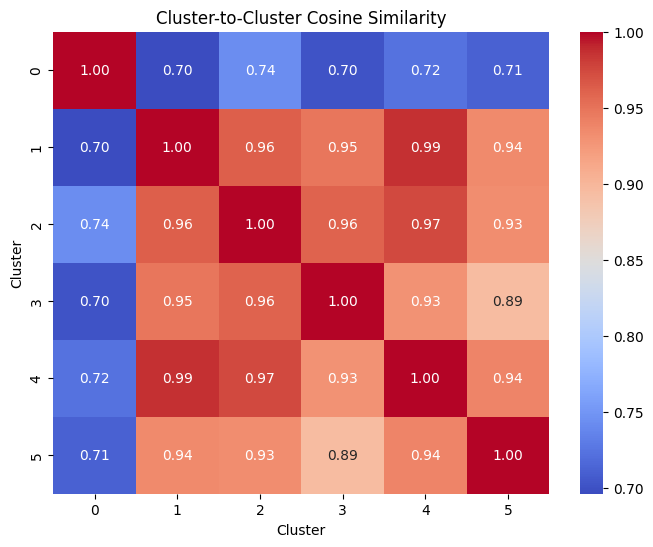

In [ ]:
# --- Plot 3: Vec2top Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df = pd.DataFrame(similarity_matrix)
sim_df.columns = [f"Topic_{i}" for i in range(num_clusters)]
sim_df.index = [f"Topic_{i}" for i in range(num_clusters)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix, np.nan)

# Find most similar cluster pairs
most_similar = np.unravel_index(np.nanargmax(similarity_matrix), similarity_matrix.shape)
print("Most similar cluster pair:", most_similar, "Similarity:", similarity_matrix[most_similar])

Most similar cluster pair: (np.int64(1), np.int64(4)) Similarity: 0.9859075381576687


## BERTopic Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex1 = topic_data1.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters1 = len(np.unique(labels_ex1))

# Compute centroids
centroids1 = np.array([
    embeddings1[labels_ex1 == i].mean(axis=0) for i in range(num_clusters1)
])

num_clusters1, centroids1

(7,
 array([[ 0.11062212, -0.50006724, -0.71833722, ..., -1.5336782 ,
          0.50848612, -0.60387394],
        [ 0.09691576, -0.52798014, -0.10182885, ..., -1.53518518,
          0.82645111, -0.63999504],
        [ 0.07457828, -0.62036599, -0.38263016, ..., -1.22391021,
          1.00552543, -0.49385647],
        ...,
        [ 0.33827343, -0.55174803, -0.34916614, ..., -1.45462486,
          0.70799167, -0.57429224],
        [ 0.11150087, -0.56043965, -0.21160497, ..., -1.72866954,
          0.84975582, -0.47365256],
        [-0.03386839, -0.82494459, -0.19526243, ..., -1.78037191,
          0.97051674, -0.48062933]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix1 = cosine_similarity(centroids1)

# Calculate centroid by cosine similarity
distance_matrix1 = euclidean_distances(centroids1)

similarity_matrix1, distance_matrix1

(array([[1.        , 0.97528536, 0.96111897, 0.97450758, 0.97464671,
         0.9794096 , 0.97638523],
        [0.97528536, 1.        , 0.97008542, 0.98586711, 0.99419714,
         0.99381791, 0.98956756],
        [0.96111897, 0.97008542, 1.        , 0.96195644, 0.97191983,
         0.9660592 , 0.96308196],
        [0.97450758, 0.98586711, 0.96195644, 1.        , 0.98163236,
         0.99554132, 0.98156169],
        [0.97464671, 0.99419714, 0.97191983, 0.98163236, 1.        ,
         0.98704069, 0.98521761],
        [0.9794096 , 0.99381791, 0.9660592 , 0.99554132, 0.98704069,
         1.        , 0.98989251],
        [0.97638523, 0.98956756, 0.96308196, 0.98156169, 0.98521761,
         0.98989251, 1.        ]]),
 array([[0.        , 7.85131511, 9.98037801, 7.99348867, 7.94966171,
         7.15545732, 7.62398088],
        [7.85131511, 0.        , 8.78484563, 5.98041922, 3.82536867,
         3.94512218, 5.11681374],
        [9.98037801, 8.78484563, 0.        , 9.90993172, 8.51219144,
  

## 🧬 **Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity**

Same interpretation as Plot 3 but for BERTopic. Results:

* **Most similar pair**: Cluster 3 and Cluster 5 with a similarity of **0.996**.
* Overall, **very high similarities** between all clusters (mostly above 0.97).

🔴 **Conclusion:**
BERTopic's topic centroids are **heavily overlapping**, implying **redundant or weakly differentiated clusters**. This aligns with its lower performance scores.

---

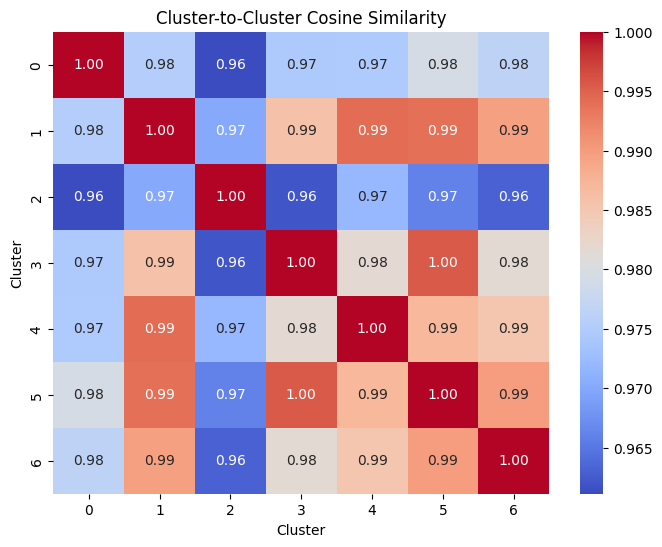

In [ ]:
# --- Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix1, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df1 = pd.DataFrame(similarity_matrix1)
sim_df1.columns = [f"Topic_{i}" for i in range(num_clusters1)]
sim_df1.index = [f"Topic_{i}" for i in range(num_clusters1)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix1, np.nan)

# Find most similar cluster pairs
most_similar1 = np.unravel_index(np.nanargmax(similarity_matrix1), similarity_matrix1.shape)
print("Most similar cluster pair:", most_similar1, "Similarity:", similarity_matrix1[most_similar1])

Most similar cluster pair: (np.int64(3), np.int64(5)) Similarity: 0.9955413212709159


## **Conclusion**

This project explored topic modeling on PubMed medical abstracts using embedding-based clustering methods powered by **ModernBERT**. Two prominent models—**Vec2Top** and **BERTopic**—were compared across the full pipeline: embedding extraction, topic discovery, naming, visualization, and quantitative evaluation.

---

### ✅ Key Results

| Metric                        | Vec2Top | BERTopic             |
| ----------------------------- | ------- | -------------------- |
| **# Topics Discovered**       | 6       | 7                    |
| **Silhouette Score**          | 0.1239  | 0.0207               |
| **Calinski-Harabasz Index**   | 321.66  | 121.97               |
| **Davies-Bouldin Score**      | 1.76    | 3.79                 |
| **Adjusted Rand Index (ARI)** | –       | **0.294** vs Vec2Top |
| **NMI Score**                 | –       | 0.226–0.228          |
| **V-measure**                 | –       | 0.226                |

---

### 🔍 Observations

* **Embedding Quality:** Pre-computed ModernBERT embeddings provided meaningful representations of abstracts.
* **Vec2Top** consistently outperformed BERTopic in terms of **cohesion and separation** of clusters.
* **BERTopic** showed more fragmented and noisy topic groupings despite similar input embeddings.
* **Topic Naming with LLMs** significantly improved the interpretability of discovered topics.

---

### 📌 Recommendations

* For biomedical or scientific datasets with rich semantics, **Vec2Top + ModernBERT + LLM topic namer** appears to be an effective pipeline.
* Further fine-tuning or domain-specific filtering may improve BERTopic performance.
* More evaluation could be added using human judgment or domain experts to assess topic relevance.
